In [2]:
from amocatlas import read
from amoc_analysis import data
import matplotlib.pyplot as plt
%load_ext autoreload

In [4]:
# Read dataset
ds = read.move()   # 16N (also: read.osnap(), read.move(),read.samba(), read.fw2015(), ...)
# ds.MOC

Loading 1 MOVE 16°N dataset(s):
  0. OS_MOVE_20000206-20221014_DPR_VOLUMETRANSPORT.nc: MOVE transport time series



In [87]:
%autoreload
from amoc_analysis.spectra_filtering.spectra import raw_periodogram
from scipy import signal
from amoc_analysis.spectra_filtering.data_io import fill_gaps

n = len(ds.MOC)
dt_days = 2.0   # 48 h = 2 days

# Nyquist freq
f_N = 1/(2*dt_days) # cycles per day (cpd)
print(f'Nyquist frequency f_N = {f_N} cycles per day (cpd)')

# Fill data gaps (NaN)
moc_filled = fill_gaps(values=ds.MOC, method='linear')

# Compute periodogram
# f, psd = raw_periodogram(x=moc_filled, dt_days=2.0, window='boxcar')
f, psd = raw_periodogram(x=moc_filled, dt_days=2.0, window='tukey')

Nyquist frequency f_N = 0.25 cycles per day (cpd)
1.0099534998720099


Nyquist frequency of 0.25 cpd means one full oscillation in 4 days

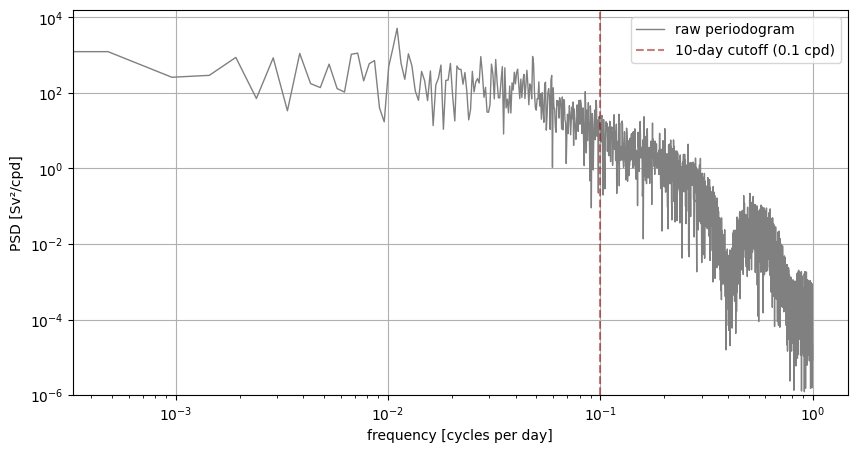

In [90]:
fig = plt.figure(figsize=(10,5))

plt.loglog(f, psd, lw=1, c='grey', alpha=1, label='raw periodogram')
plt.axvline(x=0.1, c='darkred', ls='dashed', alpha=0.5, label='10-day cutoff (0.1 cpd)')

# Fig settings
plt.ylim(bottom=1e-6)
# plt.xlim(left=1e-10)
plt.grid()
plt.legend()
plt.ylabel('PSD [Sv²/cpd]')
plt.xlabel('frequency [cycles per day]')

plt.show()